# E46 · Taming chaos: inference, prediction and control of chaotic dynamics

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | A simulated chaotic **Ricker** population (the benchmark of Wood 2010, *Nature*), then the real thing: **Nicholson's blowflies**, 180 counts of adult sheep blowflies every two days in a laboratory culture (Nicholson 1954; `blowfly` from the CRAN package `gamair`, read straight from the R data file) |
| **You will learn** | What chaos is in practice - sensitive dependence, the **Lyapunov exponent**, the bifurcation diagram · why the obvious likelihood (**trajectory matching**: simulate from an initial state, compare with data) is useless for a chaotic system: hundreds of local optima, gradients that grow like $e^{\lambda t}$, NUTS chains frozen in different modes · the fixes: **shorten the horizon** (multiple shooting) and **let process noise re-synchronise the model with the data** (a centred latent-state model) · the trap: the **non-centred** version puts the chaos back · forecasting when the weather is unpredictable but the climate is not · a delay-difference model for the blowflies with the **delay marginalised** · checking a model of a chaotic or cycling system by **features, not paths** · **is it chaos or noise?** - the posterior on the Lyapunov exponent and a regime map · **controlling chaos**: the OGY idea (tiny, well-timed nudges), and a feedback policy for the blowflies chosen by its **risk across the posterior** |

## Chaos, in one paragraph

Some systems follow exact rules and are still unpredictable. A chaotic system amplifies any
small difference in its present state - a rounding error, a fly more or less - exponentially
fast, so two almost identical starting points soon lead to completely different futures.
Weather is the famous example; insect populations, lasers, heart rhythms and chemical reactions
are others. Chaos creates three practical problems, and this notebook takes them in turn.
**Fitting**: a model that has to reproduce the whole observed path from its starting point
cannot be fitted by any ordinary method. **Predicting**: forecasts go blind after a few steps,
although the long-run *range* of behaviour stays predictable. **Controlling**: surprisingly,
chaos makes control *cheap*, because a chaotic system visits every neighbourhood of its
unstable equilibria on its own, and tiny nudges at the right moments can hold it there.

## The plan

Part one is a laboratory: a population model we know is chaotic, simulated, so that every
method can be checked against the truth (sections 1-5). Part two applies the lessons to a real
population that ecologists have argued about for seventy years (sections 6-9).

1. Chaos in one line of code: the Ricker map
2. Why the obvious likelihood fails
3. Fix: shorten the horizon, let noise re-synchronise the model
4. Forecasting a chaotic system
5. Controlling chaos with tiny nudges (OGY)
6. Nicholson's blowflies
7. A delay model, with the delay marginalised
8. Is it chaos? A regime map and the Lyapunov exponent
9. Holding the blowflies steady, under uncertainty

In [1]:
import bz2
import gzip
import logging
import lzma
import struct
import time
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import pytensor
import pytensor.tensor as pt
from matplotlib.colors import TwoSlopeNorm
from scipy import stats

from pymc_challenges import data

RANDOM_SEED = 46
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)  # several fits: no sampler banner per fit
BLUE, ORANGE, AQUA, GREY, PURPLE, RED, INK = (
    "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8c5ac8", "#c8384e", "#222222")
CHAIN_COLOURS = [BLUE, ORANGE, AQUA, PURPLE]


def stacked(da):
    """(chain, draw, ...) -> (sample, ...) NumPy array."""
    return da.stack(sample=("chain", "draw")).transpose("sample", ...).to_numpy()


print(f"PyMC {pm.__version__}, ArviZ {az.__version__}, PyTensor {pytensor.__version__}")

PyMC 6.3.2, ArviZ 1.3.0, PyTensor 3.3.2


## 1 · Chaos in one line of code: the Ricker map

The **Ricker map** (Ricker 1954, for fish stocks) is the simplest realistic population model:
each individual produces on average $r$ offspring, reduced by crowding,

$$N_{t+1} = r\, N_t\, e^{-N_t}, \qquad\text{or on the log scale}\qquad
  n_{t+1} = \log r + n_t - e^{n_t}, \quad n_t = \log N_t .$$

(Population is in units of the carrying capacity.) The equilibrium is $N^* = \log r$, and its
stability is decided by the slope of the map there, $1 - \log r$ in log units. For
$\log r < 2$ the population settles; beyond, it overshoots and oscillates, the oscillations
double their period again and again, and from $\log r \approx 2.69$ most values of $r$ give
**chaos**.

The number that measures chaos is the **Lyapunov exponent** $\lambda$: the average rate at
which nearby trajectories separate, $|\delta n_t| \approx |\delta n_0|\, e^{\lambda t}$. For a
one-dimensional map it is the long-run average of $\log |f'(n_t)|$ along the path, here
$\log|1 - e^{n_t}|$. $\lambda < 0$: a stable equilibrium or cycle; $\lambda = 0$: the edge;
$\lambda > 0$: chaos. Its inverse is the **Lyapunov time**, the number of steps over which an
error grows by a factor $e$.

Lyapunov exponent at log r = 3.8: 0.531 per step (an error grows e-fold every 1.9 steps)


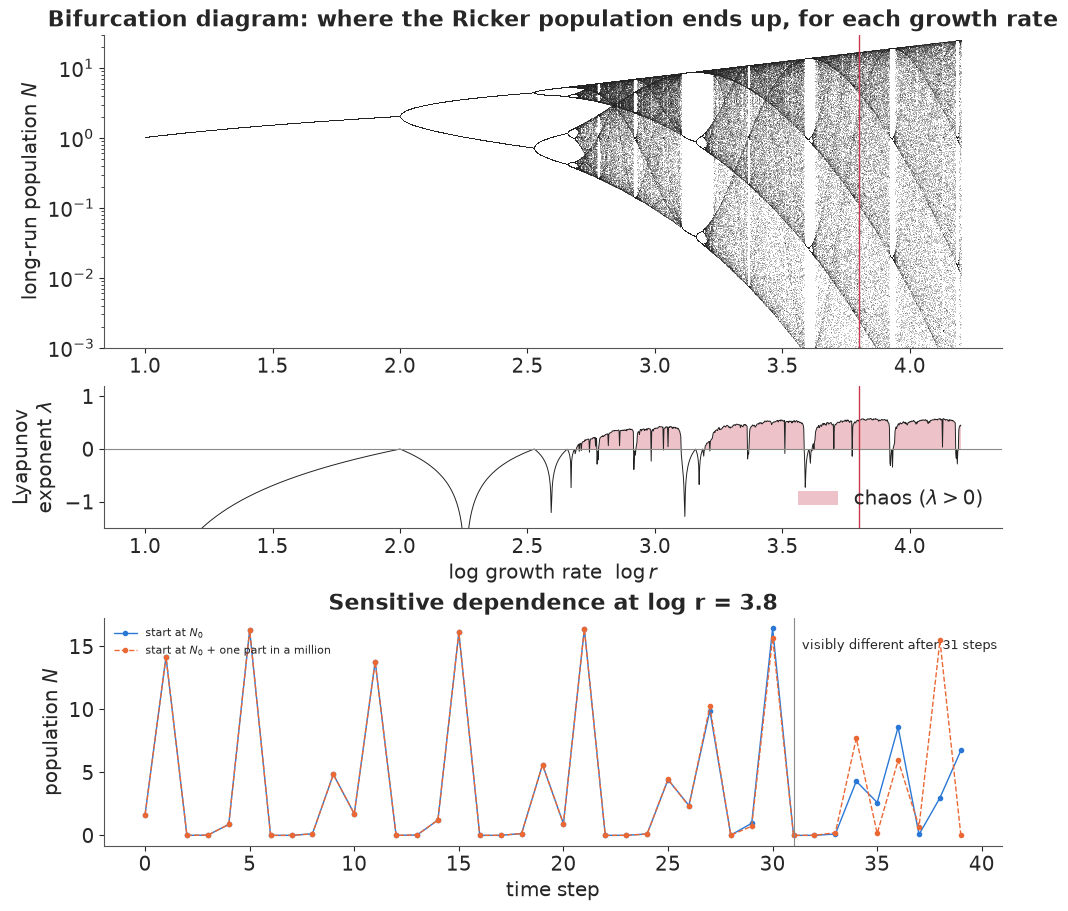

In [2]:
def ricker_path(log_r, n0, steps):
    """Deterministic Ricker map on the log scale; log_r may be an array (vectorised)."""
    log_r = np.asarray(log_r, float)
    n = np.empty((steps,) + log_r.shape)
    n[0] = n0
    for t in range(steps - 1):
        n[t + 1] = log_r + n[t] - np.exp(n[t])
    return n


def ricker_lyapunov(log_r, steps=4000, burn=500):
    n = ricker_path(log_r, 0.1, steps + burn)[burn:]
    return np.log(np.abs(1 - np.exp(n)) + 1e-300).mean(axis=0)


log_r_grid = np.linspace(1.0, 4.2, 1600)
orbit = ricker_path(log_r_grid, 0.1, 700)[-200:]      # the long-run states for each r
lyap_grid = ricker_lyapunov(log_r_grid)
LOG_R_TRUE = 3.8                                      # Wood (2010)'s value
lam_true = ricker_lyapunov(np.array([LOG_R_TRUE]))[0]
print(f"Lyapunov exponent at log r = {LOG_R_TRUE}: {lam_true:.3f} per step "
      f"(an error grows e-fold every {1 / lam_true:.1f} steps)")

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=False,
                         gridspec_kw={"height_ratios": [2.2, 1, 1.6]})
ax = axes[0]
ax.plot(np.broadcast_to(log_r_grid, orbit.shape).ravel(), np.exp(orbit).ravel(), ",", color=INK,
        alpha=0.25)
ax.axvline(LOG_R_TRUE, color=RED, lw=1)
ax.set(ylabel="long-run population $N$", yscale="log", ylim=(1e-3, 30),
       title="Bifurcation diagram: where the Ricker population ends up, for each growth rate")
ax = axes[1]
ax.plot(log_r_grid, lyap_grid, color=INK, lw=0.7)
ax.fill_between(log_r_grid, 0, lyap_grid, where=lyap_grid > 0, color=RED, alpha=0.3, lw=0,
                label="chaos ($\\lambda > 0$)")
ax.axhline(0, color=GREY, lw=0.8)
ax.axvline(LOG_R_TRUE, color=RED, lw=1)
ax.set(xlabel="log growth rate  $\\log r$", ylabel="Lyapunov\nexponent $\\lambda$", ylim=(-1.5, 1.2))
ax.legend(loc="lower right")
# The butterfly effect: two populations one part in a million apart
ax = axes[2]
steps = 40
a = ricker_path(LOG_R_TRUE, 0.5, steps)
b = ricker_path(LOG_R_TRUE, 0.5 + 1e-6, steps)
ax.plot(np.exp(a), "o-", color=BLUE, ms=3, lw=1, label="start at $N_0$")
ax.plot(np.exp(b), "o--", color=ORANGE, ms=3, lw=1, label="start at $N_0$ + one part in a million")
diverge = np.argmax(np.abs(a - b) > 0.5)
ax.axvline(diverge, color=GREY, lw=0.8)
ax.text(diverge + 0.4, 0.9 * np.exp(a).max(), f"visibly different after {diverge} steps", fontsize=9)
ax.set(xlabel="time step", ylabel="population $N$",
       title=f"Sensitive dependence at log r = {LOG_R_TRUE}")
ax.legend(loc="upper left", fontsize=8);

At Wood's value $\log r = 3.8$ the population is chaotic with $\lambda \approx 0.53$ per step: an
error is multiplied by about $e^{0.53} \approx 1.7$ each generation (e-fold every 1.9 steps), so a
difference of one part in a million becomes a completely different population after about 30
generations (bottom panel; $\log(10^6)/0.53 \approx 26$). Nothing random has happened; the rule is exact. That is the whole difficulty.

## 2 · Why the obvious likelihood fails

Now the laboratory experiment. We simulate Wood (2010)'s benchmark: a Ricker population with
**process noise** (each generation's growth is multiplied by $e^{\varepsilon_t}$,
$\varepsilon_t \sim N(0, 0.3^2)$ - good and bad years) observed through **Poisson counts**
$y_t \sim \text{Poisson}(\phi N_t)$ with $\phi = 10$ (we count a sample of the population).
We keep 100 generations for fitting and hold out the next 20 for forecasting in section 4.

first 30 counts: [  0  47  17 149   0   0   4 118   0   1  39  39  41  31 105   0   7 186
   0   0   0  26  95   0   6 178   0   0   0  11]


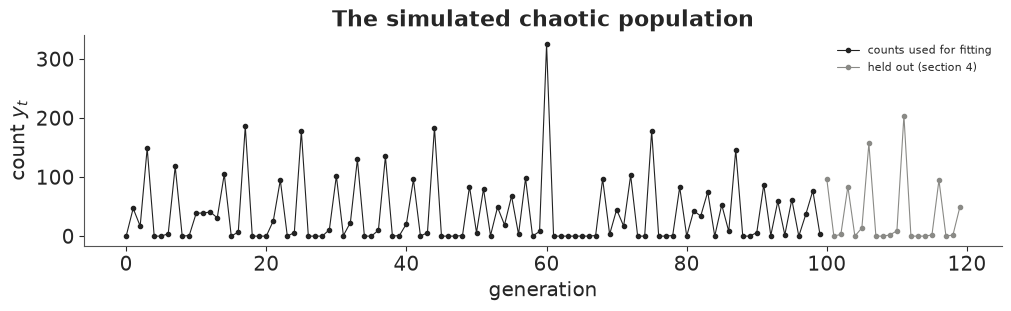

In [3]:
SIGMA_TRUE, PHI_TRUE, T_FIT, T_HOLD = 0.3, 10.0, 100, 20
sim_rng = np.random.default_rng(3)
n_true = np.empty(50 + T_FIT + T_HOLD)
n_true[0] = 0.0
for t in range(len(n_true) - 1):
    n_true[t + 1] = LOG_R_TRUE + n_true[t] - np.exp(n_true[t]) + SIGMA_TRUE * sim_rng.standard_normal()
n_true = n_true[50:]                                   # drop the burn-in
y_all = sim_rng.poisson(PHI_TRUE * np.exp(n_true))
y_lab, y_hold = y_all[:T_FIT], y_all[T_FIT:]
print("first 30 counts:", y_lab[:30])

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(np.arange(T_FIT), y_lab, "o-", color=INK, ms=3, lw=0.8, label="counts used for fitting")
ax.plot(np.arange(T_FIT, T_FIT + T_HOLD), y_hold, "o-", color=GREY, ms=3, lw=0.8,
        label="held out (section 4)")
ax.set(xlabel="generation", ylabel="count $y_t$", title="The simulated chaotic population")
ax.legend(fontsize=8);

The natural first model ignores the process noise: the population follows the deterministic
map from an unknown starting value, and all the scatter is counting noise. This is
**trajectory matching** - fitting an ODE solution or a simulator's output to data is the same
idea, and it is how most mechanistic models are fitted. The likelihood of $\log r$ (with the
start and $\phi$ fixed at their true values, to see its shape):

local maxima of the trajectory-matching likelihood on [3, 4.5]: 960; global maximum at log r = 3.035 (truth 3.8)


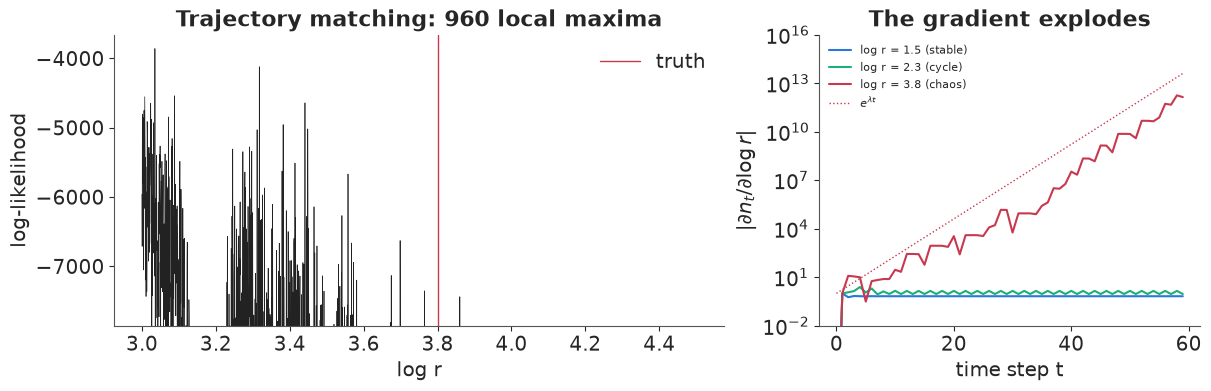

In [4]:
def trajectory_loglik(log_r, n0=n_true[0], phi=PHI_TRUE, y=y_lab):
    path = ricker_path(log_r, n0, len(y))                       # (T, grid)
    return stats.poisson.logpmf(y[:, None], phi * np.exp(path)).sum(axis=0)


profile_grid = np.linspace(3.0, 4.5, 3000)
ll_traj = trajectory_loglik(profile_grid)
n_peaks = int(np.sum((ll_traj[1:-1] > ll_traj[:-2]) & (ll_traj[1:-1] > ll_traj[2:])))
print(f"local maxima of the trajectory-matching likelihood on [3, 4.5]: {n_peaks}; "
      f"global maximum at log r = {profile_grid[np.argmax(ll_traj)]:.3f} (truth {LOG_R_TRUE})")

# Why: the sensitivity of the path to log r grows like e^{lambda t}
def path_sensitivity(log_r, steps=60):
    """d n_t / d log r along the deterministic path (a tangent recursion)."""
    n, dn, out = 0.5, 0.0, []
    for _ in range(steps):
        out.append(abs(dn))
        n, dn = log_r + n - np.exp(n), 1 + (1 - np.exp(n)) * dn
    return np.array(out)


fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={"width_ratios": [1.6, 1]})
ax = axes[0]
ax.plot(profile_grid, ll_traj, color=INK, lw=0.5)
ax.axvline(LOG_R_TRUE, color=RED, lw=1, label="truth")
ax.set(xlabel="log r", ylabel="log-likelihood", ylim=(ll_traj.max() - 4000, ll_traj.max() + 200),
       title=f"Trajectory matching: {n_peaks} local maxima")
ax.legend()
ax = axes[1]
for lr_, c, lab in [(1.5, BLUE, "log r = 1.5 (stable)"), (2.3, AQUA, "log r = 2.3 (cycle)"),
                    (LOG_R_TRUE, RED, f"log r = {LOG_R_TRUE} (chaos)")]:
    ax.semilogy(path_sensitivity(lr_) + 1e-12, color=c, label=lab)
ax.semilogy(np.arange(60), np.exp(lam_true * np.arange(60)), ":", color=RED, lw=1,
            label="$e^{\\lambda t}$")
ax.set(xlabel="time step t", ylabel="$|\\partial n_t / \\partial \\log r|$", ylim=(1e-2, 1e16),
       title="The gradient explodes")
ax.legend(fontsize=8);

Two views of one problem. **Left**: the likelihood surface is a comb of about a thousand spikes.
Moving $\log r$ by $10^{-3}$ changes the simulated path completely after a few dozen steps, so
the likelihood of the later data jumps around at random; the global maximum is not even near
the truth. **Right**: the gradient that NUTS (or any optimiser) follows is the sensitivity of
the path to the parameter, and for a chaotic map it grows like $e^{\lambda t}$ - by generation
60 it is about $10^{12}$. A stable or cycling population (blue, green) has bounded gradients.

What does NUTS make of it? The same model in PyMC, with the deterministic path in a
`pytensor.scan` and priors on $\log r$, the starting state and $\log\phi$:

In [5]:
def fit_trajectory_matching(y, seed):
    with pm.Model() as model:
        log_r = pm.Normal("log_r", 4, 1)
        n0 = pm.Normal("n0", 0, 1)
        log_phi = pm.Normal("log_phi", np.log(10), 1)
        path = pytensor.scan(lambda n, lr: lr + n - pt.exp(n), outputs_info=[n0],
                             non_sequences=[log_r], n_steps=len(y) - 1, return_updates=False)
        n = pt.concatenate([n0[None], path])
        pm.Poisson("y", pt.exp(log_phi + n), observed=y)
        return pm.sample(random_seed=seed, progressbar=False)


t0 = time.time()
idata_traj = fit_trajectory_matching(y_lab, RANDOM_SEED)
print(f"trajectory matching: {time.time() - t0:.0f} s, "
      f"{int(idata_traj.sample_stats['diverging'].sum())} divergent transitions of "
      f"{idata_traj.posterior.sizes['chain'] * idata_traj.posterior.sizes['draw']}")
print(az.summary(idata_traj, var_names=["log_r", "n0", "log_phi"], round_to=3)
      [["mean", "sd", "ess_bulk", "r_hat"]])
print("per-chain mean of log r:", idata_traj.posterior["log_r"].mean("draw").values.round(3))

trajectory matching: 21 s, 1121 divergent transitions of 4000
          mean     sd  ess_bulk   r_hat
log_r    3.392  0.333     4.053  14.719
n0      -0.093  0.421     4.220   4.893
log_phi  2.480  0.414     4.189   5.311
per-chain mean of log r: [3.461 3.131 3.068 3.907]


Each chain has found a different spike and cannot leave it: the per-chain means of $\log r$
disagree, $\hat R$ is far above 1, and most transitions diverge because the gradients are
astronomically large. Running longer or raising `target_accept` does not help: the posterior
really is a comb of spikes, and it is concentrated on the wrong answers. The model is wrong,
not the sampler. A deterministic chaotic model cannot be reconciled with 100 generations of
data, because the real population was nudged by noise every generation and the model never
is.

## 3 · Fix: shorten the horizon, let noise re-synchronise the model

The trouble comes from asking the model to predict far ahead from one starting point. Restart
it more often and the problem goes away. The figure below uses an oracle, the true state at
the start of each segment: the model is restarted every $k$ generations and predicts the next
$k$ counts (this is **multiple
shooting**, a standard trick for fitting ODEs) and the likelihood is a sum over segments.

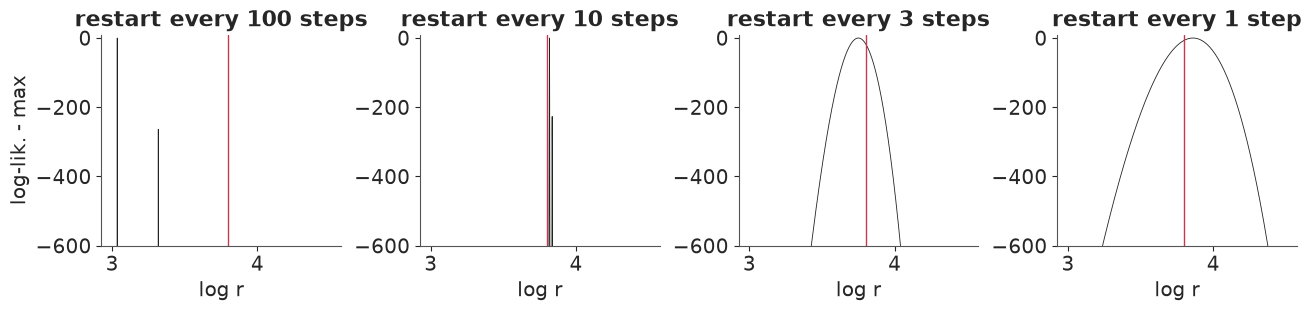

In [6]:
def segmented_loglik(log_r, k, y=y_lab):
    """Restart the deterministic map from the TRUE state every k steps (an oracle, for insight)."""
    total = 0.0
    for start in range(0, len(y) - 1, k):
        seg = y[start + 1:start + 1 + k]                        # the next k counts
        path = ricker_path(log_r, n_true[start], len(seg) + 1)[1:]
        total = total + stats.poisson.logpmf(seg[:, None], PHI_TRUE * np.exp(path)).sum(axis=0)
    return total


fig, axes = plt.subplots(1, 4, figsize=(13, 3), sharex=True)
for ax, k in zip(axes, [100, 10, 3, 1]):
    ll = segmented_loglik(profile_grid, k)
    ax.plot(profile_grid, ll - ll.max(), color=INK, lw=0.6)
    ax.axvline(LOG_R_TRUE, color=RED, lw=1)
    ax.set(title=f"restart every {k} step{'s' if k > 1 else ''}", xlabel="log r", ylim=(-600, 10))
axes[0].set_ylabel("log-lik. - max");

With restarts every 10 steps the comb has fewer, broader teeth; every 3 steps it is almost
smooth; one-step-ahead (each prediction starts from the previous true state) it is a single
smooth hill at the truth. The horizon over which the model must predict on its own is what
makes the surface rough, and it has to be short compared with the Lyapunov time.

In reality we do not know the true states. The Bayesian way to get the same effect is to make
the states **unknowns** and put the process noise in the model:

$$n_{t+1} \sim N(\log r + n_t - e^{n_t},\ \sigma^2), \qquad y_t \sim \text{Poisson}(\phi\,e^{n_t}).$$

Now each state $n_t$ only has to agree with its neighbours $n_{t-1}$, $n_{t+1}$ and its own
count $y_t$. No long-range prediction appears anywhere in the likelihood: the process noise
lets the model **re-synchronise** with the data every generation. This is what data
assimilation in weather forecasting does, and it is the general answer to fitting chaotic
systems: a state-space model with process noise. (Wood's own answer, the *synthetic
likelihood*, instead compares summary statistics of simulated and real series; see "Try it
yourself".)

In PyMC the states are a vector of free parameters (`pm.Flat`) whose joint density - the
process model - is added with a `pm.Potential`. We start the chains at the log-counts (a rough
guess of the states, which saves warm-up). Keep this **centred** form in mind; we will try the
other one next.

In [7]:
def fit_state_space(y, seed, sigma_sd=0.5):
    with pm.Model() as model:
        log_r = pm.Normal("log_r", 4, 1)
        sigma = pm.HalfNormal("sigma", sigma_sd)
        log_phi = pm.Normal("log_phi", np.log(10), 1)
        n = pm.Flat("n", shape=len(y))                            # the latent log-populations
        pm.Potential("n0_prior", pm.logp(pm.Normal.dist(0, 2), n[0]))
        pm.Potential("process", pm.logp(pm.Normal.dist(log_r + n[:-1] - pt.exp(n[:-1]), sigma),
                                        n[1:]).sum())
        pm.Poisson("y", pt.exp(log_phi + n), observed=y)
        return model, pm.sample(random_seed=seed, progressbar=False,
                                initvals={"n": np.log((y + 0.5) / 10)},
                                nuts={"adaptation": "low_rank"})


t0 = time.time()
ss_model, idata_ss = fit_state_space(y_lab, RANDOM_SEED)
print(f"centred state-space model: {time.time() - t0:.0f} s, "
      f"{int(idata_ss.sample_stats['diverging'].sum())} divergences")
summ_ss = az.summary(idata_ss, var_names=["log_r", "sigma", "log_phi"], round_to=3)
summ_ss["truth"] = [LOG_R_TRUE, SIGMA_TRUE, np.log(PHI_TRUE)]
print(summ_ss[["mean", "sd", "eti89_lb", "eti89_ub", "ess_bulk", "r_hat", "truth"]])
print("max r_hat over the 100 latent states:",
      float(az.rhat(idata_ss, var_names=["n"]).to_dataset()["n"].max()))

centred state-space model: 1 s, 0 divergences
          mean     sd  eti89_lb  eti89_ub  ess_bulk  r_hat     truth
log_r    3.841  0.100     3.682     4.002  4452.281  1.000  3.800000
sigma    0.304  0.055     0.222     0.395   330.338  1.009  0.300000
log_phi  2.297  0.030     2.250     2.345  5098.532  1.002  2.302585
max r_hat over the 100 latent states: 1.0036013258426537


The same data, the same priors, and now everything works: no divergences, $\hat R \approx 1$,
and all three parameters are recovered with the truth inside the 89% intervals. The latent
states are also estimated. The posterior of the path follows the true population through its
crashes and booms:

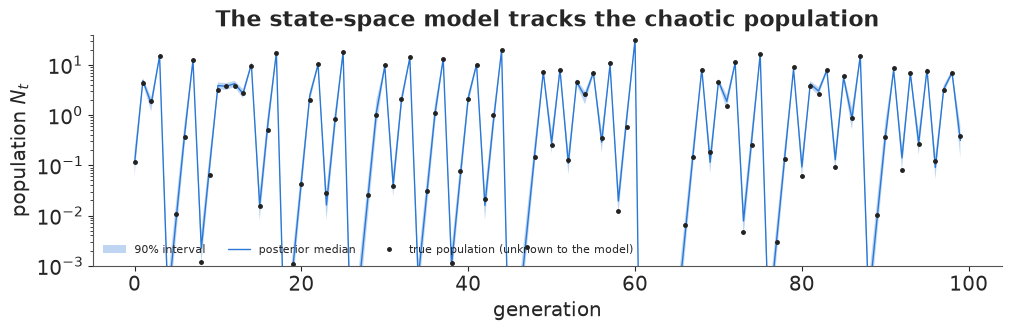

In [8]:
n_draws = stacked(idata_ss.posterior["n"])
n_lo, n_mid, n_hi = np.quantile(n_draws, [0.05, 0.5, 0.95], axis=0)
fig, ax = plt.subplots(figsize=(10, 3.2))
t_ax = np.arange(T_FIT)
ax.fill_between(t_ax, np.exp(n_lo), np.exp(n_hi), color=BLUE, alpha=0.3, lw=0, label="90% interval")
ax.plot(t_ax, np.exp(n_mid), color=BLUE, lw=1, label="posterior median")
ax.plot(t_ax, np.exp(n_true[:T_FIT]), "o", color=INK, ms=2.5, label="true population (unknown to the model)")
ax.set(yscale="log", ylim=(1e-3, 40), xlabel="generation", ylabel="population $N_t$",
       title="The state-space model tracks the chaotic population")
ax.legend(fontsize=8, ncols=3, loc="lower left");

### The trap: non-centred puts the chaos back

Elsewhere in this collection (E05, E13) the **non-centred** parameterisation - sample the
standardised innovations $z_t$ and build the states from them - is the cure for hierarchical
models. Here it is poison. The states become $n_{t+1} = \log r + n_t - e^{n_t} + \sigma z_t$
computed forward by `scan`, so every state is a *chaotic* function of all earlier innovations
and parameters: we are back to trajectory matching with extra parameters.

non-centred state-space model: 32 s, 2000 divergences
per-chain mean of log r: [3.36  4.182 4.692 3.485]
per-chain mean of sigma: [0.49  0.684 1.062 0.208]


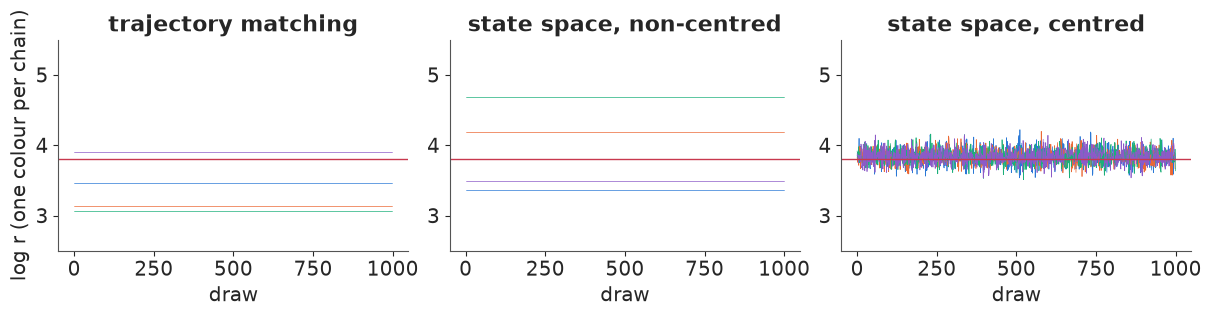

In [9]:
def fit_state_space_noncentred(y, seed):
    with pm.Model():
        log_r = pm.Normal("log_r", 4, 1)
        sigma = pm.HalfNormal("sigma", 0.5)
        log_phi = pm.Normal("log_phi", np.log(10), 1)
        n0 = pm.Normal("n0", 0, 2)
        z = pm.Normal("z", 0, 1, shape=len(y) - 1)
        path = pytensor.scan(lambda zt, n, lr, s: lr + n - pt.exp(n) + s * zt, sequences=[z],
                             outputs_info=[n0], non_sequences=[log_r, sigma], return_updates=False)
        pm.Poisson("y", pt.exp(log_phi + pt.concatenate([n0[None], path])), observed=y)
        return pm.sample(random_seed=seed, progressbar=False)


t0 = time.time()
idata_nc = fit_state_space_noncentred(y_lab, RANDOM_SEED)
print(f"non-centred state-space model: {time.time() - t0:.0f} s, "
      f"{int(idata_nc.sample_stats['diverging'].sum())} divergences")
print("per-chain mean of log r:", idata_nc.posterior["log_r"].mean("draw").values.round(3))
print("per-chain mean of sigma:", idata_nc.posterior["sigma"].mean("draw").values.round(3))

fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharex=True)
for ax, (name, idata_x) in zip(axes, [("trajectory matching", idata_traj),
                                      ("state space, non-centred", idata_nc),
                                      ("state space, centred", idata_ss)]):
    for c in range(idata_x.posterior.sizes["chain"]):
        ax.plot(idata_x.posterior["log_r"].isel(chain=c).values, color=CHAIN_COLOURS[c], lw=0.5)
    ax.axhline(LOG_R_TRUE, color=RED, lw=1)
    ax.set(title=name, xlabel="draw", ylim=(2.5, 5.5))
axes[0].set_ylabel("log r (one colour per chain)");

The trace plots tell the story: the trajectory-matching chains (left) and the non-centred
chains (middle) each sit in their own local mode, while the centred chains (right) mix around
the truth. **Rule: for a chaotic system, the sampler's coordinates must be the states
themselves, never quantities that the chaotic map turns into states.** The same applies to
ODE and SDE models with chaotic dynamics (Lorenz, double pendulum, turbulence): sample the
latent path directly, or use a filter (particle filter, ensemble Kalman filter) that
re-synchronises at each observation.

## 4 · Forecasting a chaotic system

Chaos limits *prediction*, not *knowledge*. The posterior pins down $\log r$ and the current
state quite well; how far ahead does that let us see? We simulate forward from each posterior
draw of the last state and the parameters (with process noise), and compare with the 20 held-out
generations.

skill (log score gain) for leads 1-6: [ 1.36  0.4   0.35  0.03 -0.11 -0.3 ]


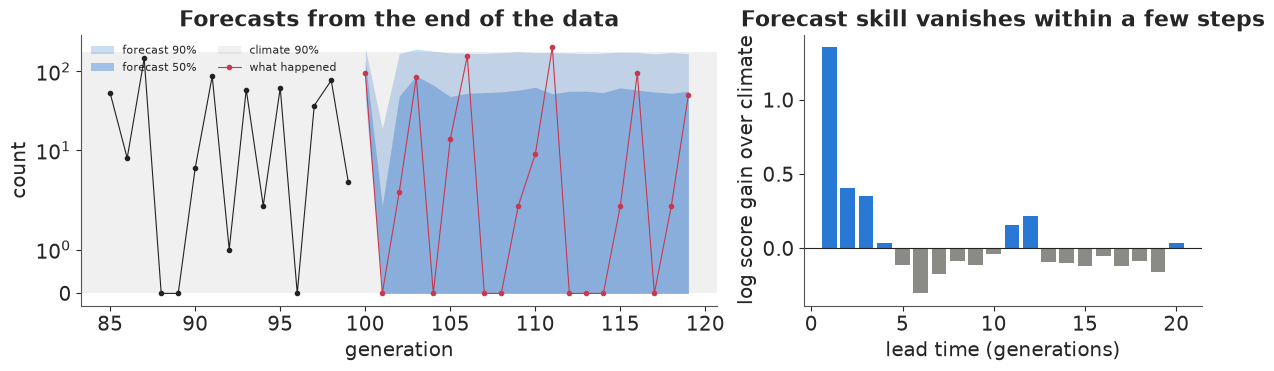

In [10]:
post_ss = az.extract(idata_ss, var_names=["log_r", "sigma", "log_phi"])
log_r_d, sigma_d, log_phi_d = (post_ss[v].values for v in ["log_r", "sigma", "log_phi"])
n_last = n_draws[:, -1]
fc_rng = np.random.default_rng(RANDOM_SEED)
fc = np.empty((len(n_last), T_HOLD))
state = n_last.copy()
for h in range(T_HOLD):
    state = log_r_d + state - np.exp(state) + sigma_d * fc_rng.standard_normal(len(state))
    fc[:, h] = state
y_fc = fc_rng.poisson(np.exp(log_phi_d[:, None] + fc))

# The "climate": the long-run distribution of counts, from a long simulation at the posterior
n_long = np.empty(20000)
n_long[0] = 0.1
for t in range(len(n_long) - 1):
    n_long[t + 1] = log_r_d.mean() + n_long[t] - np.exp(n_long[t]) + sigma_d.mean() * fc_rng.standard_normal()
y_climate = fc_rng.poisson(np.exp(log_phi_d.mean() + n_long[500:]))

# Skill: how much better than the climate is the forecast at each lead time? (log score)
def log_score(samples, obs):
    pmf = np.bincount(np.minimum(samples, 999), minlength=1000) + 0.5
    return np.log(pmf[min(obs, 999)] / pmf.sum())


skill = np.array([log_score(y_fc[:, h], y_hold[h]) - log_score(y_climate, y_hold[h])
                  for h in range(T_HOLD)])
fc_q = np.quantile(y_fc, [0.05, 0.25, 0.5, 0.75, 0.95], axis=0)
clim_q = np.quantile(y_climate, [0.05, 0.95])

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), gridspec_kw={"width_ratios": [1.6, 1]})
ax = axes[0]
t_hold = np.arange(T_FIT, T_FIT + T_HOLD)
ax.plot(np.arange(T_FIT - 15, T_FIT), y_lab[-15:], "o-", color=INK, ms=3, lw=0.8)
ax.fill_between(t_hold, fc_q[0], fc_q[4], color=BLUE, alpha=0.25, lw=0, label="forecast 90%")
ax.fill_between(t_hold, fc_q[1], fc_q[3], color=BLUE, alpha=0.4, lw=0, label="forecast 50%")
ax.axhspan(*clim_q, color=GREY, alpha=0.12, lw=0, label="climate 90%")
ax.plot(t_hold, y_hold, "o-", color=RED, ms=3, lw=0.8, label="what happened")
ax.set(xlabel="generation", ylabel="count", yscale="symlog", title="Forecasts from the end of the data")
ax.legend(fontsize=8, ncols=2, loc="upper left")
ax = axes[1]
ax.bar(np.arange(1, T_HOLD + 1), skill, color=np.where(skill > 0, BLUE, GREY))
ax.axhline(0, color=INK, lw=0.8)
ax.set(xlabel="lead time (generations)", ylabel="log score gain over climate",
       title="Forecast skill vanishes within a few steps");
print("skill (log score gain) for leads 1-6:", skill[:6].round(2))

For the first three generations the forecast is sharp and clearly better than knowing only
the long-run range of counts (the "climate"). Then the forecast fan spreads to cover the whole
attractor, and the skill drops to about zero (bars around zero are luck). This is the
weather/climate distinction: we cannot say *when* the next crash comes after a few
generations, but we can say with confidence how often crashes happen and how deep they go.
With $\lambda \approx 0.53$ and process noise of 0.3 on top, the horizon is short; a chaotic
system with smaller noise and smaller $\lambda$ would be predictable for longer, but never
indefinitely.

## 5 · Controlling chaos with tiny nudges (OGY)

Ott, Grebogi & Yorke (1990, *Physical Review Letters*) noticed that chaos is a gift for
control. A chaotic attractor is threaded by *unstable* equilibria and cycles, and the chaotic
path passes close to each of them again and again. So there is no need to force the system;
wait until it comes near the state you want, and then apply a **small** correction at each
step to keep it there. The corrections are small because the system is already close; a
stable (non-chaotic) system would never come close on its own.

For the Ricker population the equilibrium $n^* = \log(\log r)$ is unstable (slope
$1 - \log r \approx -2.8$: deviations nearly triple, and flip sign, each generation). Our
control variable is a small change $u_t$ in the growth rate (more or less food, a small
harvest): $n_{t+1} = \log r + u_t + n_t - e^{n_t}$, with $|u_t| \le u_{\max}$. The rule: if
the one-step prediction misses $n^*$ by less than $u_{\max}$, choose $u_t$ to hit $n^*$
exactly; otherwise do nothing and wait.

noise-free: captured after 33 steps; afterwards |u| <= 2.2e-16
with noise sd 0.05: mean |u| after capture = 0.098, max = 0.482


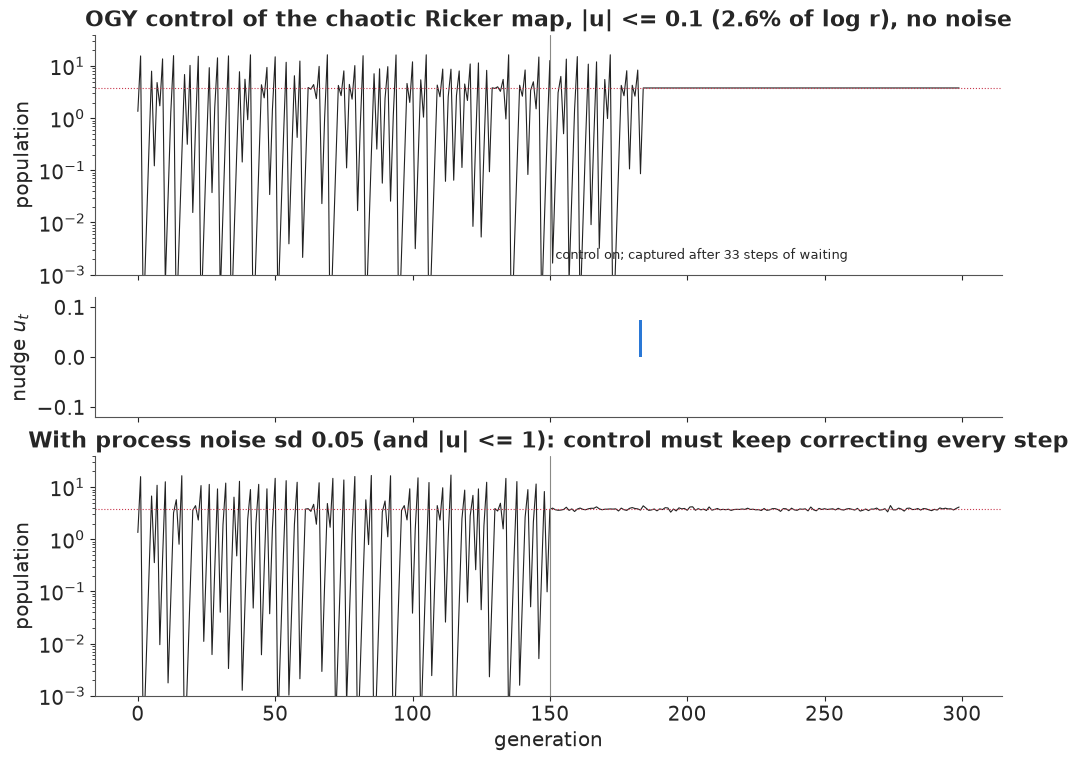

In [11]:
def ogy_run(log_r, u_max, sigma, steps=300, start=150, seed=0):
    r_ = np.random.default_rng(seed)
    target = np.log(log_r)
    n, us = np.empty(steps), np.zeros(steps)
    n[0] = 0.3
    for t in range(steps - 1):
        pred = log_r + n[t] - np.exp(n[t])
        if t >= start and abs(target - pred) < u_max:
            us[t] = target - pred
        n[t + 1] = pred + us[t] + sigma * r_.standard_normal()
    return n, us


fig, axes = plt.subplots(3, 1, figsize=(10, 7.5), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1, 2]})
n_ctl, u_ctl = ogy_run(LOG_R_TRUE, u_max=0.1, sigma=0.0)
ax = axes[0]
ax.plot(np.exp(n_ctl), color=INK, lw=0.8)
ax.axvline(150, color=GREY, lw=0.8)
ax.axhline(LOG_R_TRUE, color=RED, lw=0.8, ls=":")
captured = 150 + np.argmax(np.abs(u_ctl[150:]) > 0)
ax.text(152, 2e-3, f"control on; captured after {captured - 150} steps of waiting", fontsize=9)
ax.set(ylabel="population", yscale="log", ylim=(1e-3, 40),
       title=f"OGY control of the chaotic Ricker map, |u| <= 0.1 (2.6% of log r), no noise")
ax = axes[1]
ax.bar(np.arange(len(u_ctl)), u_ctl, color=BLUE, width=1)
ax.set(ylabel="nudge $u_t$", ylim=(-0.12, 0.12))
n_ctl2, u_ctl2 = ogy_run(LOG_R_TRUE, u_max=1.0, sigma=0.05, seed=1)
ax = axes[2]
ax.plot(np.exp(n_ctl2), color=INK, lw=0.8)
ax.axvline(150, color=GREY, lw=0.8)
ax.axhline(LOG_R_TRUE, color=RED, lw=0.8, ls=":")
ax.set(xlabel="generation", ylabel="population", yscale="log", ylim=(1e-3, 40),
       title="With process noise sd 0.05 (and |u| <= 1): control must keep correcting every step");
print(f"noise-free: captured after {captured - 150} steps; "
      f"afterwards |u| <= {np.abs(u_ctl[captured + 5:]).max():.1e}")
print(f"with noise sd 0.05: mean |u| after capture = "
      f"{np.abs(u_ctl2[200:]).mean():.3f}, max = {np.abs(u_ctl2[200:]).max():.3f}")

Without noise the controller does nothing for a while, then the chaotic path wanders into the
window, one nudge of less than 0.1 moves it onto the equilibrium, and from then on it stays
there with essentially zero effort: an unstable equilibrium is still an equilibrium. With
noise, every random kick of size $\sigma$ has to be undone before it is amplified, and the
required nudge is about $|1 - \log r| \cdot \sigma$ per step - small, but never zero. With
the lab's full noise ($\sigma = 0.3$) it would be almost 1 in log units each generation: OGY
control works best when the system is chaotic and the noise is small. The same idea has
stabilised lasers, heart tissue (Garfinkel et al. 1992) and a chaotic flour-beetle population
(Desharnais et al. 2001).

Three things were needed: the location of the unstable state, how the system responds to the
nudge, and a model of the one-step dynamics. All three come from a fitted model, so the
uncertainty about them should enter the choice of controller. Part two does that on real data.

## 6 · Nicholson's blowflies

In the 1950s the Australian entomologist A. J. Nicholson kept cultures of the sheep blowfly
*Lucilia cuprina* in cages with a fixed daily ration of food and counted the adults every two
days for about a year. The populations did not settle down: they swung between a few hundred
and several thousand flies in large, irregular cycles. Whether those cycles are chaos, a
regular cycle blurred by noise, or something in between has been argued ever since (Gurney,
Blythe & Nisbet 1980; Ellner & Turchin 1995; Wood 2010). We read the series from the R data
file distributed with `gamair`, with the small XDR reader from E23/E39/E41.

blowfly: R data file (bzip2-compressed XDR): a data frame `blowfly` of 180 counts of adult sheep blowflies (Lucilia cuprina) in one of Nicholson's laboratory cultures, one count every two days: pop (adults; back-calculated from counts of dead flies) and day (an index, 0.5 to 90 in steps of 0.5).
  source: Nicholson (1954), An outline of the dynamics of animal populations, Australian Journal of Zoology 2:9-65; as distributed in the CRAN package gamair (Wood, Generalized Additive Models).
  url:    https://raw.githubusercontent.com/cran/gamair/master/data/blowfly.rda
180 counts over 358 days; min 60, median 1756, max 8921 adults
autocorrelation of log counts peaks at lag 19 (= 38 days)


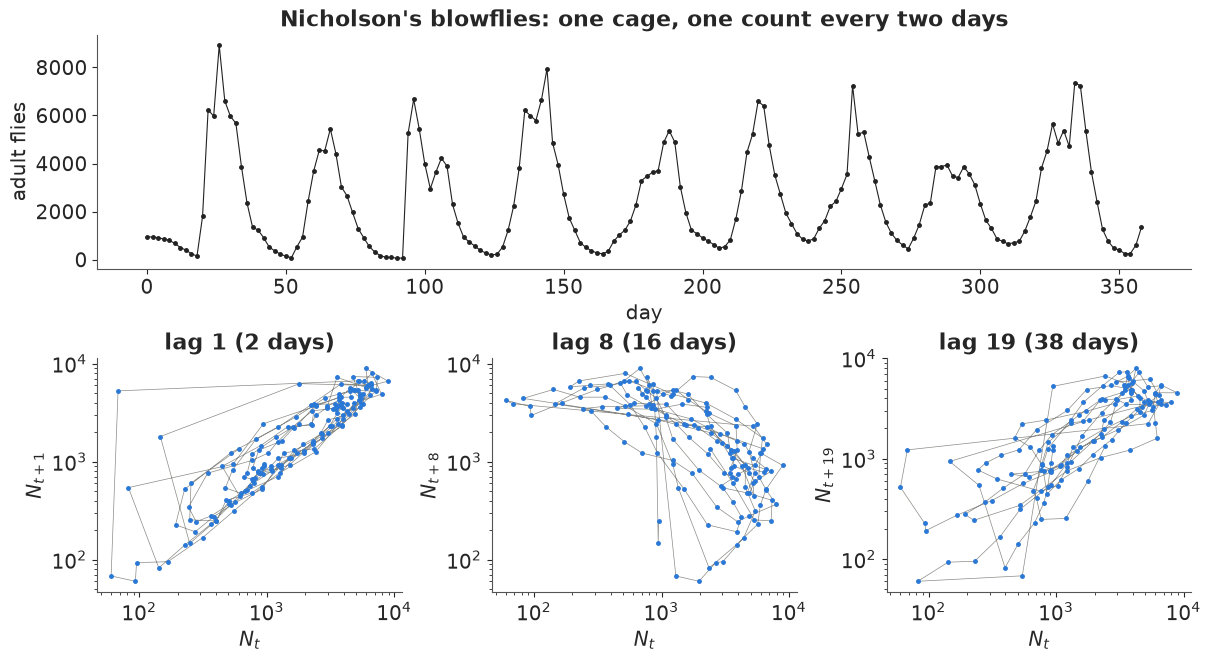

In [12]:
def read_rdata(path):
    """Minimal reader for R's XDR serialisation (gzip, bzip2 or xz): named lists, vectors, strings."""
    raw = Path(path).read_bytes()
    buf = (bz2.decompress(raw) if raw[:2] == b"BZ" else
           lzma.decompress(raw) if raw[:6] == b"\xfd7zXZ\x00" else gzip.decompress(raw))
    assert buf[:7] in (b"RDX2\nX\n", b"RDX3\nX\n"), "not an XDR R data file"
    pos, refs = 7, []

    def i32():
        nonlocal pos
        pos += 4
        return struct.unpack(">i", buf[pos - 4:pos])[0]

    def item():
        nonlocal pos
        flags = i32()
        kind, has_attr, has_tag = flags & 0xFF, flags & (1 << 9), flags & (1 << 10)
        if kind == 254:                                     # NULL
            return None
        if kind == 255:                                     # reference to an earlier symbol
            return refs[(flags >> 8) - 1]
        if kind == 1:                                       # symbol
            refs.append(item())
            return refs[-1]
        if kind == 9:                                       # string
            n = i32()
            pos += max(n, 0)
            return None if n == -1 else buf[pos - n:pos].decode()
        if kind == 2:                                       # pairlist -> dict
            out = {}
            while kind == 2:
                _ = item() if has_attr else None
                tag = item() if has_tag else None
                out[tag] = item()
                flags = i32()
                kind, has_attr, has_tag = flags & 0xFF, flags & (1 << 9), flags & (1 << 10)
            return out
        n = i32()
        if kind in (10, 13):                                # logical / integer
            value, pos = np.frombuffer(buf, ">i4", n, pos).astype(int), pos + 4 * n
        elif kind == 14:                                    # double
            value, pos = np.frombuffer(buf, ">f8", n, pos).astype(float), pos + 8 * n
        elif kind in (16, 19):                              # character vector / list
            value = [item() for _ in range(n)]
        else:
            raise NotImplementedError(f"R type {kind}")
        attrs = item() if has_attr else None
        if kind == 19 and attrs and "names" in attrs:
            value = dict(zip(attrs["names"], value))
        return value

    version = i32()
    pos += 8
    if version == 3:
        pos += 4 + struct.unpack(">i", buf[pos:pos + 4])[0]
    return item()


data.describe("blowfly")
flies = read_rdata(data.path("blowfly"))["blowfly"]
N_obs = np.asarray(flies["pop"], float)
days = 2 * np.arange(len(N_obs))                     # one count every two days
print(f"{len(N_obs)} counts over {days[-1]} days; min {N_obs.min():.0f}, "
      f"median {np.median(N_obs):.0f}, max {N_obs.max():.0f} adults")
x_c = np.log(N_obs) - np.log(N_obs).mean()
acf = np.array([x_c[:-k] @ x_c[k:] / (x_c @ x_c) for k in range(1, 60)])
acf_peak = 1 + np.argmax(np.r_[0, (acf[1:-1] > acf[:-2]) & (acf[1:-1] > acf[2:]), 0] * acf)
print(f"autocorrelation of log counts peaks at lag {acf_peak} (= {2 * acf_peak} days)")

fig = plt.figure(figsize=(12, 6.5))
gs = fig.add_gridspec(2, 3)
ax = fig.add_subplot(gs[0, :])
ax.plot(days, N_obs, "o-", color=INK, ms=2.5, lw=0.8)
ax.set(xlabel="day", ylabel="adult flies", title="Nicholson's blowflies: one cage, one count every two days")
for i, lag in enumerate([1, 8, acf_peak]):
    ax = fig.add_subplot(gs[1, i])
    ax.plot(N_obs[:-lag], N_obs[lag:], "-", color=GREY, lw=0.5)
    ax.plot(N_obs[:-lag], N_obs[lag:], "o", color=BLUE, ms=2.5)
    ax.set(xlabel=f"$N_t$", ylabel=f"$N_{{t+{lag}}}$", xscale="log", yscale="log",
           title=f"lag {lag} ({2 * lag} days)")

The population cycles with a period of about 38 days (autocorrelation peak at lag 19), with
irregular amplitude: some peaks are twice as high as others, some troughs ten times deeper.
The lag plots show structure: at lag 1 the path moves smoothly round a loop; at lag 8
(16 days, the order of the time from egg to adult) it traces a wide loop, as a delayed
feedback would.

## 7 · A delay model, with the delay marginalised

The biology suggests a **delay-difference model** (the discrete-time version of Gurney,
Blythe & Nisbet's blowfly equation, as used by Wood 2010). Adults at census $t+1$ are the
survivors of today's adults plus the new adults that emerge from eggs laid $\tau$ steps ago,
when crowding at the food cut egg production:

$$N_{t+1} = \underbrace{P\, N_{t-\tau}\, e^{-N_{t-\tau}/N_0}}_{\text{emerging adults}}
  \;+\; \underbrace{s\, N_t}_{\text{survivors}}, $$

with $P$ the maximum per-capita production per step, $N_0$ the population at which crowding
bites, $s$ the adult survival over two days and $\tau$ the development delay in steps.
Following section 3, we use the observed counts as the states and let multiplicative process
noise re-synchronise the model every step: $N_{t+1} \sim \text{LogNormal}(\log m_t, \sigma)$,
where $m_t$ is the right-hand side. (Counts of thousands of flies are precise compared with
the 30-40% process noise we will find; with noisy counts we would need latent states as in
section 3.) Every term predicts only one step ahead, so the likelihood is smooth.

The delay $\tau$ is an integer. Rather than guess it, we **marginalise** it: compute the
likelihood for each $\tau$ from 4 to 13 steps (8-26 days), give each the same prior weight
and add them up with `logsumexp`. The posterior probability of each delay is then
$p(\tau \mid \theta, y)$ averaged over the posterior of the other parameters.

Priors: $\log P \sim N(\log 5, 1)$ (a few new adults per adult every two days at low
density), $\log N_0 \sim N(\log 1000, 1)$ (crowding at hundreds to thousands of flies, the
scale of the cage), $s \sim \text{Beta}(4, 2)$ (an adult fly lives a few weeks, so two-day
survival is likely 0.5-0.9) and $\sigma \sim \text{HalfNormal}(0.5)$. The model is
scale-free in $N_0$: it only sets the units, and the dynamics depend on $P$, $s$ and $\tau$.

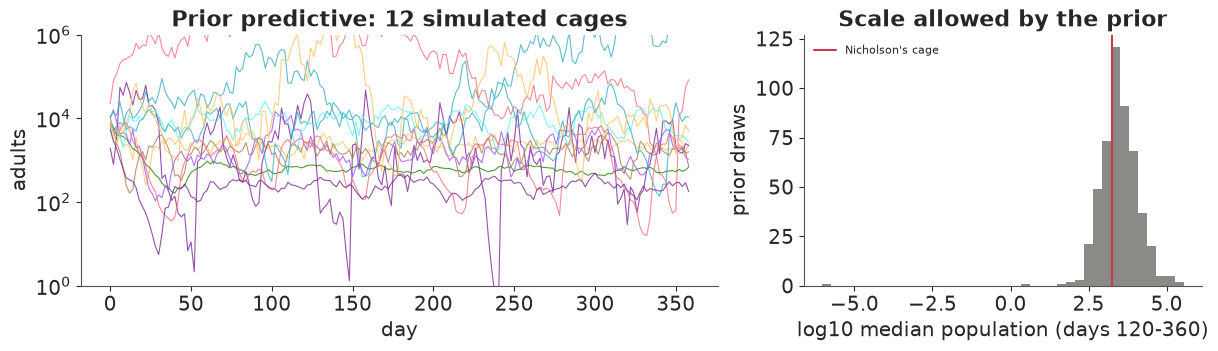

In [13]:
TAUS = np.arange(4, 14)
T0 = TAUS.max()                                    # first step with every lag available
y_b = N_obs[T0:]
prev_b = N_obs[T0 - 1:-1]
lags_b = np.stack([N_obs[T0 - k:len(N_obs) - k] for k in TAUS])   # (delay, time)

with pm.Model(coords={"tau": TAUS}) as blowfly_model:
    log_P = pm.Normal("log_P", np.log(5), 1)
    log_N0 = pm.Normal("log_N0", np.log(1000), 1)
    s = pm.Beta("s", 4, 2)
    sigma = pm.HalfNormal("sigma", 0.5)
    m = pt.exp(log_P) * lags_b * pt.exp(-lags_b / pt.exp(log_N0)) + s * prev_b
    loglik_tau = pm.logp(pm.LogNormal.dist(pt.log(m), sigma), y_b[None, :]).sum(axis=1)
    pm.Potential("likelihood", pt.logsumexp(loglik_tau) - np.log(len(TAUS)))
    pm.Deterministic("p_tau", pt.exp(loglik_tau - pt.logsumexp(loglik_tau)), dims="tau")

# Prior predictive in NumPy (a Potential has no generative form): what do the priors allow?
def simulate_blowflies(P, N0, s, sigma, tau, steps, start, seed, control=None):
    """Simulate the delay model for many parameter draws at once (one row per draw).

    start: the first max(tau)+1 counts (oldest first). control(t, N_t) returns the number of
    adults added (+) or removed (-) right after the census at step t.
    """
    r_ = np.random.default_rng(seed)
    D = len(P)
    tau = np.broadcast_to(tau, (D,))
    width = tau.max() + 1
    hist = np.tile(np.asarray(start, float)[-width:][::-1], (D, 1))   # column k holds N_{t-k}
    out, us = np.empty((D, steps)), np.zeros((D, steps))
    rows = np.arange(D)
    for t in range(steps):
        if control is not None:
            us[:, t] = control(t, hist[:, 0])
            hist[:, 0] = hist[:, 0] + us[:, t]
        lag = hist[rows, tau]
        mean = P * lag * np.exp(-lag / N0) + s * hist[:, 0]
        new = mean * np.exp(sigma * r_.standard_normal(D)) if sigma is not None else mean
        hist = np.concatenate([new[:, None], hist[:, :-1]], axis=1)
        out[:, t] = new
    return out, us


pr = np.random.default_rng(RANDOM_SEED)
n_prior = 500
prior_draws = dict(P=np.exp(pr.normal(np.log(5), 1, n_prior)), N0=np.exp(pr.normal(np.log(1000), 1, n_prior)),
                   s=pr.beta(4, 2, n_prior), sigma=np.abs(pr.normal(0, 0.5, n_prior)),
                   tau=pr.choice(TAUS, n_prior))
with np.errstate(over="ignore", invalid="ignore"):
    prior_paths, _ = simulate_blowflies(**prior_draws, steps=180, start=N_obs[:T0 + 1], seed=1)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4), gridspec_kw={"width_ratios": [1.6, 1]})
ax = axes[0]
for i in range(12):
    ax.plot(2 * np.arange(180), prior_paths[i], lw=0.8, alpha=0.8)
ax.set(yscale="log", ylim=(1, 1e6), xlabel="day", ylabel="adults", title="Prior predictive: 12 simulated cages")
ax = axes[1]
prior_level = np.log10(np.median(prior_paths[:, 60:], axis=1))
ax.hist(prior_level[np.isfinite(prior_level)], bins=40, color=GREY)
ax.axvline(np.log10(np.median(N_obs)), color=RED, label="Nicholson's cage")
ax.set(xlabel="log10 median population (days 120-360)", ylabel="prior draws", title="Scale allowed by the prior")
ax.legend(fontsize=8);

The priors allow populations from tens to hundreds of thousands, steady or cycling or
erratic: wide, but not absurd. Now the fit (nutpie, default settings):

In [14]:
t0 = time.time()
with blowfly_model:
    idata_b = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
print(f"{time.time() - t0:.0f} s, {int(idata_b.sample_stats['diverging'].sum())} divergences, "
      f"{idata_b.posterior.attrs.get('tuning_steps')} tuning steps")
print(az.summary(idata_b, var_names=["log_P", "log_N0", "s", "sigma"], round_to=3)
      [["mean", "sd", "eti89_lb", "eti89_ub", "ess_bulk", "r_hat"]])
p_tau = idata_b.posterior["p_tau"].mean(("chain", "draw")).to_series()
print("posterior probability of each delay (steps of 2 days):")
print(p_tau.round(3).to_string())

1 s, 0 divergences, 400 tuning steps
         mean     sd  eti89_lb  eti89_ub  ess_bulk  r_hat
log_P   2.405  0.242     2.004     2.777  1479.888  1.003
log_N0  5.899  0.086     5.766     6.040  1556.572  1.003
s       0.809  0.028     0.765     0.853  2727.569  1.002
sigma   0.365  0.021     0.334     0.400  3203.829  1.001
posterior probability of each delay (steps of 2 days):
tau
4     0.000
5     0.000
6     0.000
7     0.001
8     0.998
9     0.001
10    0.000
11    0.000
12    0.000
13    0.000


Clean sampling. The data choose a delay of **8 steps (16 days)** with probability 0.99 and
7 steps as the only other candidate; about two weeks is the order of the egg-to-adult
development time of blowflies at laboratory temperatures, a check we did not build in. Adult two-day survival is
about 0.81 (a mean adult life of about $2/(1 - 0.81) \approx 10$ days). The process noise is
large, $\sigma \approx 0.36$: a cage's next count is only predictable to within about ±35%.
$P$ and $N_0$ are correlated (production and crowding trade off) but both are well
identified.

From here on we use posterior draws, each with its delay drawn from its own $p(\tau \mid
\theta, y)$.

In [15]:
post_b = az.extract(idata_b, var_names=["log_P", "log_N0", "s", "sigma", "p_tau"])
draw_rng = np.random.default_rng(RANDOM_SEED)
P_d, N0_d = np.exp(post_b["log_P"].values), np.exp(post_b["log_N0"].values)
s_d, sigma_b_d = post_b["s"].values, post_b["sigma"].values
p_tau_d = post_b["p_tau"].transpose("sample", "tau").values
tau_d = TAUS[(draw_rng.random(len(P_d))[:, None] > np.cumsum(p_tau_d, axis=1)).sum(axis=1)]
print("delay of the posterior draws:", dict(zip(*np.unique(tau_d, return_counts=True))))

delay of the posterior draws: {np.int64(7): np.int64(4), np.int64(8): np.int64(3994), np.int64(9): np.int64(2)}


**Checking a model of a cycling or chaotic system.** A free-running simulation from the
fitted model will never reproduce the observed path point by point - and section 1 says it
should not, if there is chaos or noise. So we check two things instead. (1) The one-step-ahead
predictions, which *are* supposed to be right. (2) **Features** of free-running simulations
that do not depend on the phase: the typical level, the size of the swings, the cycle length
and the depth of the troughs. This is the idea behind Wood's synthetic likelihood, used here
as a check.

one-step 90% interval coverage: 0.93
simulated cycle length (steps), 5/25/50/75/95%: [22. 23. 25. 27. 31.] observed 19


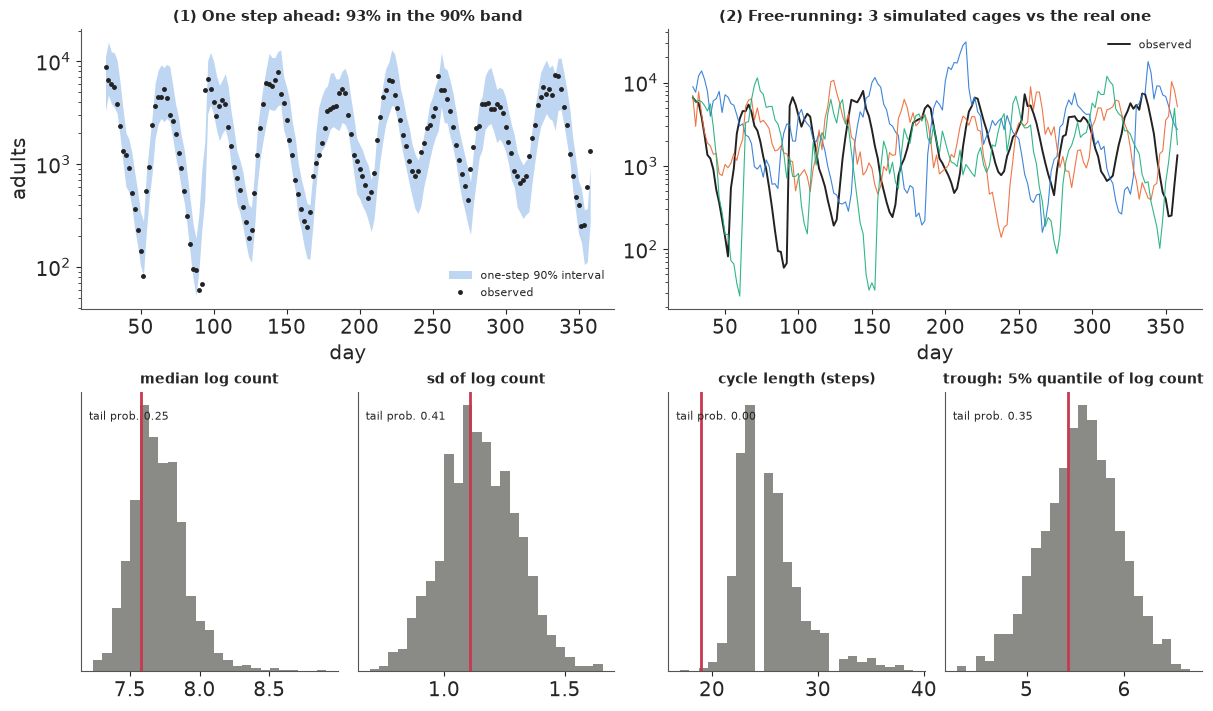

In [16]:
sub = draw_rng.choice(len(P_d), 1000, replace=False)
# (1) one-step-ahead predictive intervals, conditional on the observed history
lag_obs = np.stack([N_obs[T0 - k:len(N_obs) - k] for k in tau_d[sub]])
mean_1 = P_d[sub, None] * lag_obs * np.exp(-lag_obs / N0_d[sub, None]) + s_d[sub, None] * prev_b
pred_1 = mean_1 * np.exp(sigma_b_d[sub, None] * draw_rng.standard_normal(mean_1.shape))
q1 = np.quantile(pred_1, [0.05, 0.5, 0.95], axis=0)
cover_1 = np.mean((y_b >= q1[0]) & (y_b <= q1[2]))
# (2) free-running simulations started from the first counts
sims, _ = simulate_blowflies(P_d[sub], N0_d[sub], s_d[sub], sigma_b_d[sub], tau_d[sub],
                             steps=len(N_obs) - T0 - 1, start=N_obs[:T0 + 1], seed=2)


def features(paths):
    """Phase-free summaries of (draws, time) series of counts."""
    logp = np.log(np.atleast_2d(paths))
    xc = logp - logp.mean(axis=1, keepdims=True)
    acfs = np.stack([(xc[:, :-k] * xc[:, k:]).sum(1) / (xc * xc).sum(1) for k in range(1, 41)], 1)
    lags = np.arange(1, 41)
    is_peak = (acfs[:, 1:-1] > acfs[:, :-2]) & (acfs[:, 1:-1] > acfs[:, 2:]) & (acfs[:, 1:-1] > 0.1)
    is_peak &= lags[1:-1] >= 8
    peak = np.where(is_peak.any(axis=1), lags[1:-1][np.argmax(is_peak, axis=1)], np.nan)
    return {"median log count": np.median(logp, axis=1),
            "sd of log count": logp.std(axis=1),
            "cycle length (steps)": peak,
            "trough: 5% quantile of log count": np.quantile(logp, 0.05, axis=1)}


f_sim, f_obs = features(sims), features(N_obs[T0 + 1:])
fig = plt.figure(figsize=(12, 7))
gs = fig.add_gridspec(2, 4)
ax = fig.add_subplot(gs[0, :2])
ax.fill_between(days[T0:], q1[0], q1[2], color=BLUE, alpha=0.3, lw=0, label="one-step 90% interval")
ax.plot(days[T0:], y_b, "o", color=INK, ms=2.5, label="observed")
ax.set(yscale="log", xlabel="day", ylabel="adults",
       title=f"(1) One step ahead: {100 * cover_1:.0f}% in the 90% band")
ax.title.set_fontsize(11)
ax.legend(fontsize=8)
ax = fig.add_subplot(gs[0, 2:])
ax.plot(days[T0 + 1:], N_obs[T0 + 1:], color=INK, lw=1.4, label="observed")
for i, c in zip(range(3), [BLUE, ORANGE, AQUA]):
    ax.plot(days[T0 + 1:], sims[i], color=c, lw=0.8, alpha=0.9)
ax.set(yscale="log", xlabel="day", title="(2) Free-running: 3 simulated cages vs the real one")
ax.title.set_fontsize(11)
ax.legend(fontsize=8)
for j, (name, vals) in enumerate(f_sim.items()):
    ax = fig.add_subplot(gs[1, j])
    vals = vals[np.isfinite(vals)]
    ax.hist(vals, bins=25, color=GREY)
    ax.axvline(f_obs[name][0], color=RED, lw=2)
    ax.set(title=name, yticks=[])
    ax.title.set_fontsize(10)
    tail = min(np.mean(vals <= f_obs[name][0]), np.mean(vals >= f_obs[name][0]))
    ax.text(0.03, 0.9, f"tail prob. {tail:.2f}", transform=ax.transAxes, fontsize=8)
print(f"one-step 90% interval coverage: {cover_1:.2f}")
print("simulated cycle length (steps), 5/25/50/75/95%:",
      np.nanquantile(f_sim["cycle length (steps)"], [0.05, 0.25, 0.5, 0.75, 0.95]),
      f"observed {f_obs['cycle length (steps)'][0]:.0f}")

The one-step 90% intervals hold 93% of the counts (slightly wide, fine). The simulated cages
show the same kind of large, irregular cycles, out of phase with each other and with the data
as expected. Three features - level, size of the swings, depth of the troughs - sit well
inside the simulated spread. The fourth does not: **the simulated cycles are too long**,
typically 23-27 steps against the observed 19 (38 days), and almost no simulation is as fast
as the real cage. The simulations are also spikier than the data from one count to the next.
Both point at the noise model: one multiplicative noise on the whole population is too crude
(a quick trial with separate noises found births far noisier than deaths), and
it may be what lengthens the cycles. This is
exactly the kind of flaw a path-by-path comparison could never have shown, and we carry it
as a caveat into sections 8 and 9 (and into "Try it yourself").

## 8 · Is it chaos? A regime map and the Lyapunov exponent

The fitted skeleton (the model without noise) has a definite long-run behaviour for each
parameter draw - equilibrium, cycle or chaos - and we can compute its Lyapunov exponent. The
state is now the last $\tau + 1$ counts, so we follow a small perturbation vector through the
linearised map (the **tangent map**) and renormalise it at every step; the average log growth
is the largest Lyapunov exponent. Because the model is scale-free in $N_0$, the dynamics for a
given delay depend on $(P, s)$ only, so one **regime map** shows every possibility, and we can
put the posterior on it.

Lyapunov computations: 2 s
skeleton exponent: median 0.0000, 90% interval -0.0003 to 0.0003; P(lambda > 0.01) = 0.000
noisy exponent: median -0.0024, 90% interval -0.0048 to -0.0002; P(lambda > 0) = 0.037
chaotic share of the map (lambda > 0.01): 0.25; highest survival with chaos anywhere on the map: 0.66; at P = 11 (the posterior median) chaos needs s below 0.52


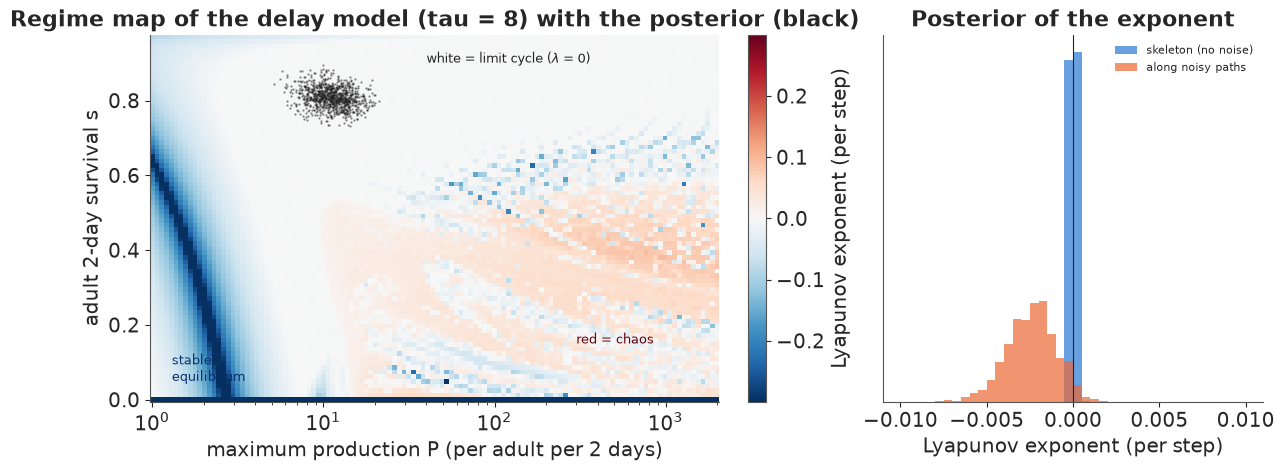

In [17]:
def delay_lyapunov(P, N0, s, tau, sigma=None, steps=3000, burn=500, seed=0):
    """Largest Lyapunov exponent of the delay model (per step), vectorised over draws.

    sigma=None: the deterministic skeleton. With sigma: along noisy paths, using the same
    random multipliers for the path and its tangent (Ellner & Turchin's 'noisy' exponent).
    """
    r_ = np.random.default_rng(seed)
    D = len(P)
    tau = np.broadcast_to(tau, (D,))
    width = tau.max() + 1
    rows = np.arange(D)
    x = np.full((D, width), 1.0) * N0[:, None]
    v = r_.standard_normal((D, width))
    total = np.zeros(D)
    for t in range(steps + burn):
        lag, vlag = x[rows, tau], v[rows, tau]
        e = np.exp(sigma * r_.standard_normal(D)) if sigma is not None else 1.0
        births = P * lag * np.exp(-lag / N0) * e
        slope = P * np.exp(-lag / N0) * (1 - lag / N0) * e
        x = np.concatenate([(births + s * x[:, 0])[:, None], x[:, :-1]], axis=1)
        v = np.concatenate([(slope * vlag + s * v[:, 0])[:, None], v[:, :-1]], axis=1)
        norm = np.maximum(np.sqrt((v**2).sum(axis=1)), 1e-300)
        v /= norm[:, None]
        if t >= burn:
            total += np.log(norm)
    return total / steps


P_grid = np.exp(np.linspace(np.log(1), np.log(2000), 120))
s_grid = np.linspace(0.0, 0.97, 80)
PP, SS = np.meshgrid(P_grid, s_grid)
t0 = time.time()
lam_map = delay_lyapunov(PP.ravel(), np.full(PP.size, 1000.0), SS.ravel(), 8).reshape(PP.shape)
lam_skel = delay_lyapunov(P_d[sub], N0_d[sub], s_d[sub], tau_d[sub])
lam_noisy = delay_lyapunov(P_d[sub], N0_d[sub], s_d[sub], tau_d[sub], sigma=sigma_b_d[sub])
print(f"Lyapunov computations: {time.time() - t0:.0f} s")
print(f"skeleton exponent: median {np.median(lam_skel):.4f}, 90% interval "
      f"{np.quantile(lam_skel, 0.05):.4f} to {np.quantile(lam_skel, 0.95):.4f}; "
      f"P(lambda > 0.01) = {np.mean(lam_skel > 0.01):.3f}")
print(f"noisy exponent: median {np.median(lam_noisy):.4f}, 90% interval "
      f"{np.quantile(lam_noisy, 0.05):.4f} to {np.quantile(lam_noisy, 0.95):.4f}; "
      f"P(lambda > 0) = {np.mean(lam_noisy > 0):.3f}")
chaos_s = SS[lam_map > 0.01]
col = np.argmin(np.abs(P_grid - np.median(P_d)))
print(f"chaotic share of the map (lambda > 0.01): {np.mean(lam_map > 0.01):.2f}; highest survival "
      f"with chaos anywhere on the map: {chaos_s.max():.2f}; at P = {P_grid[col]:.0f} (the posterior "
      f"median) chaos needs s below {s_grid[lam_map[:, col] > 0.01].max():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw={"width_ratios": [1.5, 1]})
ax = axes[0]
mesh = ax.pcolormesh(PP, SS, np.clip(lam_map, -0.3, 0.3), cmap="RdBu_r",
                     norm=TwoSlopeNorm(vcenter=0, vmin=-0.3, vmax=0.3), shading="auto")
fig.colorbar(mesh, ax=ax, label="Lyapunov exponent (per step)")
ax.plot(P_d[sub], s_d[sub], ".", color=INK, ms=1.5, alpha=0.4)
ax.set(xscale="log", xlabel="maximum production P (per adult per 2 days)", ylabel="adult 2-day survival s",
       title="Regime map of the delay model (tau = 8) with the posterior (black)")
ax.text(1.3, 0.05, "stable\nequilibrium", color="#08306b", fontsize=9)
ax.text(40, 0.9, "white = limit cycle ($\\lambda$ = 0)", fontsize=9)
ax.text(300, 0.15, "red = chaos", color="#67000d", fontsize=9)
ax = axes[1]
bins = np.linspace(-0.01, 0.01, 41)
ax.hist(np.clip(lam_skel, -0.01, 0.01), bins=bins, color=BLUE, alpha=0.7, label="skeleton (no noise)")
ax.hist(np.clip(lam_noisy, -0.01, 0.01), bins=bins, color=ORANGE, alpha=0.7, label="along noisy paths")
ax.axvline(0, color=INK, lw=0.8)
ax.set(xlabel="Lyapunov exponent (per step)", yticks=[], title="Posterior of the exponent")
ax.legend(fontsize=8);

The answer is **no, but chaos is nearby**. For every posterior draw the deterministic skeleton
has $\lambda \approx 0$: a **stable limit cycle** (the white band of the regime map). Following
the noisy paths (Ellner & Turchin's version, which asks whether *the system as it actually runs*
amplifies small differences) gives exponents slightly below zero: the noise does not tip the
cycle into chaos either. So the irregularity of Nicholson's cycles is best read, within this
model, as **a regular cycle pushed around by large random variation** ($\sigma \approx 0.36$),
not deterministic chaos. The regime map also says what would change that: chaos (red) needs
adult survival well below the posterior's 0.81 (the printout gives the threshold), not more
eggs. Costantino et al. (1997, *Science*) pushed flour-beetle cultures into chaos in exactly
this way, by raising adult mortality experimentally.

Two lessons for dealing with chaos in other problems. First, *irregular is not chaotic*: a
noisy cycle and a chaotic attractor can look alike, and the way to tell them apart is a model
with noise, fitted in a way chaos cannot break, and then the Lyapunov exponent as a posterior
quantity. Second, the answer is conditional on the model. The feature check showed that this
model's cycles run somewhat long, and a richer noise structure (separate noise for births and
deaths, as in Wood 2010) could move the posterior on the map. Report "not chaotic *under this
model*", with the map showing how far away the boundary is.

## 9 · Holding the blowflies steady, under uncertainty

Suppose the cage is a production colony (blowflies are reared for sterile-insect releases and
for teaching) and we want a *steady* supply: remove or add a few adults after each census to
damp the cycles. Section 5's principle applies. The model has an equilibrium

$$N^* = N_0 \log\!\frac{P}{1 - s}$$

(set $N_{t+1} = N_t = N_{t-\tau}$), unstable, which the population keeps swinging through. A
simple feedback rule steers towards it: after each census, add $u_t = -K\,(N_t - N^*)$ adults
(negative = remove), capped at half the adults present. Section 5 also warned what to expect:
with noise, control has to keep correcting, and it cannot remove the noise of the next two days.
Even perfect control leaves an sd of log counts of about $\sigma \approx 0.36$ (the **noise
floor**), against about 1.1 without control.

The decision is the gain $K$, and its consequences depend on parameters we know only up to
the posterior. So we simulate the controlled cage **once per posterior draw** (each with its
own $N^*$, delay and noise) and look at the spread of outcomes.

In [18]:
N_star_d = N0_d * np.log(P_d / (1 - s_d))
print(f"posterior of the equilibrium N*: median {np.median(N_star_d):.0f}, 90% interval "
      f"{np.quantile(N_star_d, 0.05):.0f} to {np.quantile(N_star_d, 0.95):.0f} "
      f"(mean of the counts: {N_obs.mean():.0f})")

CONTROL_ON, HORIZON = 60, 360          # switch on after 120 days; judge days 240-720


def run_policy(K, target, draws, seed=5):
    """Simulate the controlled cage for each draw; return per-draw summaries and the paths."""
    P_, N0_, s_, sig_, tau_ = draws

    def control(t, N_now):
        if t < CONTROL_ON:
            return np.zeros_like(N_now)
        return np.clip(-K * (N_now - target), -0.5 * N_now, 0.5 * N_now)

    paths, us = simulate_blowflies(P_, N0_, s_, sig_, tau_, steps=HORIZON, start=N_obs[:T0 + 1],
                                   seed=seed, control=control)
    judge = slice(CONTROL_ON + 60, HORIZON)
    sd_log = np.log(paths[:, judge]).std(axis=1)
    handled = np.abs(us[:, judge]).sum(axis=1) / paths[:, judge].sum(axis=1)
    return sd_log, handled, paths, us


draws_sub = (P_d[sub], N0_d[sub], s_d[sub], sigma_b_d[sub], tau_d[sub])
gains = np.array([0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0])
sweep = [run_policy(K, N_star_d[sub], draws_sub)[:2] for K in gains]
sd_q = np.array([np.quantile(a, [0.05, 0.5, 0.95]) for a, _ in sweep])
h_q = np.array([np.quantile(b, [0.05, 0.5, 0.95]) for _, b in sweep])
for K, a, b in zip(gains, sd_q, h_q):
    print(f"K={K:<4}  sd(log N): median {a[1]:.3f}, 95th pct {a[2]:.3f}   "
          f"adults handled per census: median {100 * b[1]:.1f}%")

posterior of the equilibrium N*: median 1479, 90% interval 1364 to 1615 (mean of the counts: 2481)
K=0.0   sd(log N): median 1.129, 95th pct 1.358   adults handled per census: median 0.0%
K=0.05  sd(log N): median 0.976, 95th pct 1.165   adults handled per census: median 3.4%
K=0.1   sd(log N): median 0.847, 95th pct 1.021   adults handled per census: median 6.1%
K=0.15  sd(log N): median 0.740, 95th pct 0.903   adults handled per census: median 8.2%
K=0.2   sd(log N): median 0.658, 95th pct 0.806   adults handled per census: median 9.9%
K=0.3   sd(log N): median 0.544, 95th pct 0.663   adults handled per census: median 12.5%
K=0.4   sd(log N): median 0.479, 95th pct 0.571   adults handled per census: median 14.6%
K=0.5   sd(log N): median 0.438, 95th pct 0.514   adults handled per census: median 16.7%
K=0.6   sd(log N): median 0.413, 95th pct 0.476   adults handled per census: median 18.7%
K=0.8   sd(log N): median 0.385, 95th pct 0.436   adults handled per census: median 22.8%
K=1.0 

The gain buys steadiness with flies, with diminishing returns as the sd approaches the noise
floor. A decision rule that uses the posterior: **the smallest gain that halves the swings
(sd of log counts at most 0.55) in 95% of the plausible worlds**. For comparison, the
**plug-in** design picks the smallest gain that meets the same goal in the single world of the
posterior-mean parameters (averaged over 20 noise seeds), and we then check how often each
choice misses the goal across the posterior.

posterior-risk choice K = 0.5: misses the goal in 0.9% of plausible worlds, handles 17% of adults per census
plug-in choice        K = 0.3: misses the goal in 45.9% of plausible worlds, handles 12% of adults per census


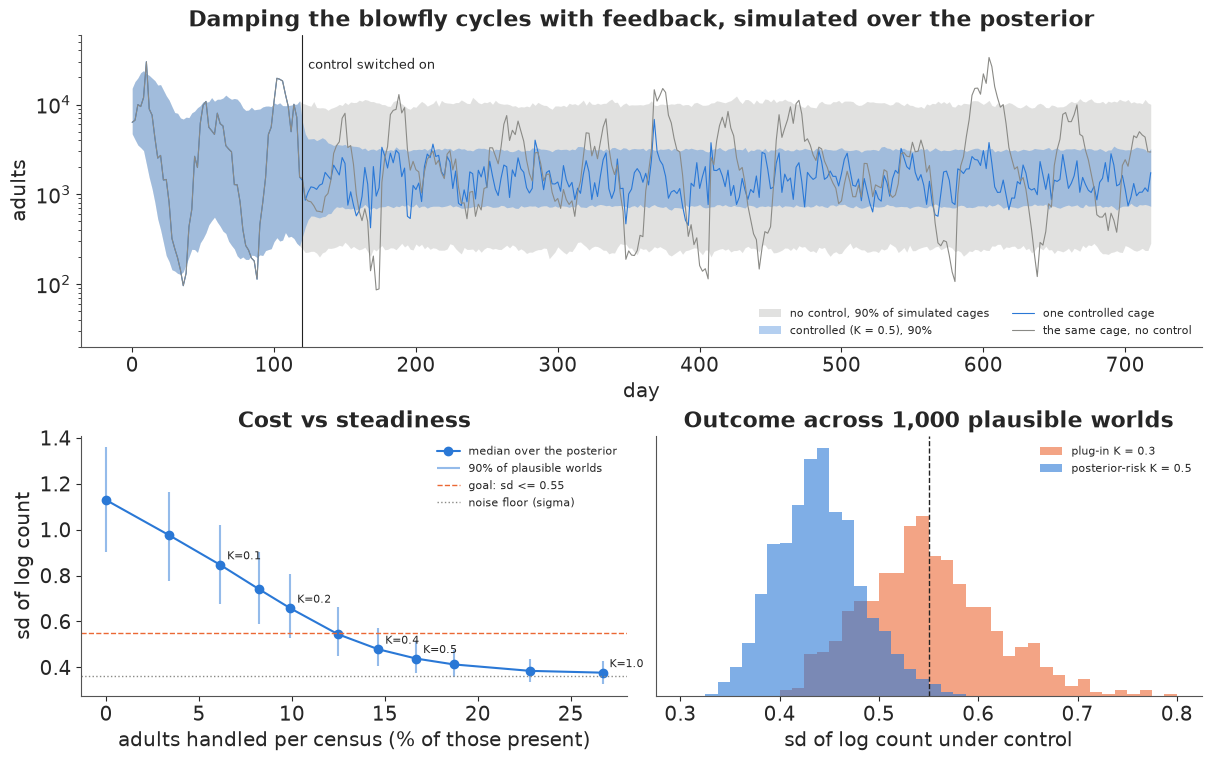

In [19]:
GOAL = 0.55
K_bayes = gains[np.argmax(sd_q[:, 2] <= GOAL)]
plug_draws = tuple(np.array([np.mean(v)]) for v in (P_d, N0_d, s_d, sigma_b_d)) + (np.array([8]),)
plug_N_star = plug_draws[1] * np.log(plug_draws[0] / (1 - plug_draws[2]))
plug_sd = np.array([np.mean([run_policy(K, plug_N_star, plug_draws, seed=k)[0][0] for k in range(20)])
                    for K in gains])
K_plugin = gains[np.argmax(plug_sd <= GOAL)]
sd_bayes, h_bayes, paths_c, us_c = run_policy(K_bayes, N_star_d[sub], draws_sub)
sd_plugin, h_plugin, _, _ = run_policy(K_plugin, N_star_d[sub], draws_sub)
print(f"posterior-risk choice K = {K_bayes}: misses the goal in {np.mean(sd_bayes > GOAL):.1%} of "
      f"plausible worlds, handles {100 * np.median(h_bayes):.0f}% of adults per census")
print(f"plug-in choice        K = {K_plugin}: misses the goal in {np.mean(sd_plugin > GOAL):.1%} of "
      f"plausible worlds, handles {100 * np.median(h_plugin):.0f}% of adults per census")

fig = plt.figure(figsize=(12, 7.5))
gs = fig.add_gridspec(2, 2, height_ratios=[1.2, 1])
ax = fig.add_subplot(gs[0, :])
free_paths, _ = simulate_blowflies(*draws_sub, steps=HORIZON, start=N_obs[:T0 + 1], seed=5)
t_days = 2 * np.arange(HORIZON)
ax.fill_between(t_days, *np.quantile(free_paths, [0.05, 0.95], axis=0), color=GREY, alpha=0.25, lw=0,
                label="no control, 90% of simulated cages")
ax.fill_between(t_days, *np.quantile(paths_c, [0.05, 0.95], axis=0), color=BLUE, alpha=0.35, lw=0,
                label=f"controlled (K = {K_bayes}), 90%")
ax.plot(t_days, paths_c[0], color=BLUE, lw=0.8, label="one controlled cage")
ax.plot(t_days, free_paths[0], color=GREY, lw=0.8, label="the same cage, no control")
ax.axvline(2 * CONTROL_ON, color=INK, lw=0.8)
ax.text(2 * CONTROL_ON + 4, 2.5e4, "control switched on", fontsize=9)
ax.set(yscale="log", ylim=(20, 6e4), xlabel="day", ylabel="adults",
       title="Damping the blowfly cycles with feedback, simulated over the posterior")
ax.legend(fontsize=8, loc="lower right", ncols=2)
ax = fig.add_subplot(gs[1, 0])
ax.plot(100 * h_q[:, 1], sd_q[:, 1], "o-", color=BLUE, label="median over the posterior")
ax.vlines(100 * h_q[:, 1], sd_q[:, 0], sd_q[:, 2], color=BLUE, alpha=0.5, label="90% of plausible worlds")
for K, hx, sy in zip(gains, 100 * h_q[:, 1], sd_q[:, 1]):
    if K in (0.1, 0.2, 0.4, K_bayes, 1.0):
        ax.annotate(f"K={K}", (hx, sy), textcoords="offset points", xytext=(5, 4), fontsize=8)
ax.axhline(GOAL, color=ORANGE, ls="--", lw=1, label="goal: sd <= 0.55")
ax.axhline(np.median(sigma_b_d), color=GREY, ls=":", lw=1, label="noise floor (sigma)")
ax.set(xlabel="adults handled per census (% of those present)", ylabel="sd of log count",
       title="Cost vs steadiness")
ax.legend(fontsize=8)
ax = fig.add_subplot(gs[1, 1])
bins = np.linspace(0.3, 0.8, 41)
ax.hist(sd_plugin, bins=bins, color=ORANGE, alpha=0.6, label=f"plug-in K = {K_plugin}")
ax.hist(sd_bayes, bins=bins, color=BLUE, alpha=0.6, label=f"posterior-risk K = {K_bayes}")
ax.axvline(GOAL, color=INK, ls="--", lw=1)
ax.set(xlabel="sd of log count under control", yticks=[], title="Outcome across 1,000 plausible worlds")
ax.legend(fontsize=8);

What the posterior says about controlling this population:

- **Feedback damps the cycles, but this population is not cheap to steady.** The rule holds
  the population in a band less than half as wide (on the log scale) as the free cycles, at
  the cost of adding or removing about one adult in six at every census. Doing better runs
  into the noise floor: two days of random births and deaths are beyond any controller that
  acts once per census. This is section 5's lesson in real numbers - OGY-style control is
  cheap when the noise is small compared with the deterministic dynamics, and Nicholson's
  cage is dominated by noise.
- **Design against the posterior, not a point estimate.** The plug-in gain meets the goal in
  the posterior-mean world, but that world is a typical one, so in a large share of the
  plausible worlds the same gain misses (the printout gives the numbers). The posterior-risk
  choice pays a few more flies per census to meet the goal almost everywhere. With less data
  the gap would be larger.
- **The model is what makes the controller possible.** The target $N^*$ (about 1,480 flies,
  ±8%) is not the average count (2,480), and the delay, the survival and the noise level set
  how the population answers each nudge. All of them came out of the fit, with their
  uncertainty.
- **Caveat.** These are simulations from a model whose cycles run a little long (section 7).
  A real controller should start with a small gain, keep counting and update the posterior:
  data from the controlled cage are informative about the very parameters it depends on.

## Summary: how to deal with chaos in a problem

1. **Do not fit long free-running trajectories.** For a chaotic (or nearly chaotic) system the
   trajectory-matching likelihood is a comb of spikes and its gradients grow like
   $e^{\lambda t}$; NUTS chains freeze in different spikes, and more samples or higher
   `target_accept` cannot fix a model that denies the process noise (section 2).
2. **Keep every prediction in the likelihood short.** Put process noise in the model and make
   the **states** the sampler's coordinates (centred state-space model), or condition on
   observed states when they are precise (one-step-ahead likelihood), or restart often
   (multiple shooting), or use a filter. The non-centred form hands the chaos back to the
   sampler (section 3).
3. **Check dynamics by features, not by paths**: one-step predictions, cycle length, spread,
   trough depth. A simulation that is out of phase with the data is not a failure (section 7).
4. **Forecast distributions, and know the horizon.** Skill decays on the Lyapunov time scale;
   beyond it, the long-run distribution (the climate) is the honest forecast (section 4).
5. **Ask whether it is chaos at all.** Put the Lyapunov exponent in the posterior and place
   the posterior on a regime map. Nicholson's irregular blowfly cycles are a noisy stable
   cycle, not chaos (section 8).
6. **Chaos is cheap to control when noise is small.** Unstable equilibria are visited anyway;
   small, well-timed nudges hold the system there. Noise raises the price and sets a floor.
   Take the target and the gain from the posterior, and judge a policy by its risk across the
   plausible worlds, not in the posterior-mean world (sections 5 and 9).

## Try it yourself

1. **Wood's synthetic likelihood** (E14 builds the machinery). Fit the Ricker lab data with
   `pm.Simulator` and `pm.sample_smc` (`cores=2`), using summary statistics such as the mean
   count, the number of
   zeros, autocorrelations and the coefficients of a regression of $y_{t+1}^{0.3}$ on
   $y_t^{0.3}$. How close is the posterior to the state-space one of section 3, and how much
   longer does it take?
2. **Push the blowflies into chaos.** Pick a point in the red region of the regime map (say
   $P = 500$, $s = 0.3$), simulate 180 counts with the fitted noise, refit the model of
   section 7 and compute the posterior of the Lyapunov exponent. Does the fit recover the
   chaos? Then control the simulated cage with the rule of section 9: how does the handling
   cost compare with the non-chaotic case?
3. **A better noise model.** Section 7 found the cycles too long. Give births and survivors
   separate noise (moment-match their sum with a log-normal, or use latent births), refit, and
   redo the feature check, the regime map and the control sweep. Which conclusions move?